# 03 — EDA: Spatial Join, Supply Indicators, and Equity Narrative

Builds on 02_data_cleaning.ipynb. **eⱼ is now filtered to on-street EVSEs only**, matching
the proposal's "existing on-street supply" definition — earlier versions used all
registered EVSEs regardless of location_category (supermarkets, destinations, etc.),
which is a scope mismatch this version corrects.

## 0. Setup and reload cleaned data

In [1]:
import pandas as pd
import numpy as np
import geopandas as gpd
import matplotlib.pyplot as plt
import os
from scipy.stats import pearsonr

BASE = "/Users/alexia/Documents/CASA/Dissertation"

census_london = pd.read_csv(os.path.join(BASE, "05_processed/census_london_clean.csv"))
imd_london    = pd.read_csv(os.path.join(BASE, "05_processed/imd_london_clean.csv"))
osev_london   = pd.read_csv(os.path.join(BASE, "05_processed/osev_london_clean.csv"))
zapmap_clean  = pd.read_csv(os.path.join(BASE, "05_processed/zapmap_clean.csv"), parse_dates=["charging_start"])
evse_ur       = pd.read_csv(os.path.join(BASE, "05_processed/evse_ur_clean.csv"))
gla_evse_join = pd.read_csv(os.path.join(BASE, "03_data/restricted/gla/gla_location_evse_join.csv"))

figures_dir = os.path.join(BASE, "06_outputs/figures")
os.makedirs(figures_dir, exist_ok=True)

# Ensure consistent ID types before filtering/joining
osev_london["location_id"] = osev_london["location_id"].astype(str)
gla_evse_join["location_id"] = gla_evse_join["location_id"].astype(str)

print("Datasets reloaded.")
print(f"census_london: {census_london.shape}, imd_london: {imd_london.shape}")
print(f"osev_london: {osev_london.shape}, zapmap_clean: {zapmap_clean.shape}")
print(f"evse_ur: {evse_ur.shape}, gla_evse_join: {gla_evse_join.shape}")

Datasets reloaded.
census_london: (4994, 8), imd_london: (4994, 10)
osev_london: (23015, 11), zapmap_clean: (63105, 20)
evse_ur: (10465, 6), gla_evse_join: (38514, 2)


In [2]:
lsoa_boundaries = gpd.read_file(os.path.join(BASE, "03_data/demand/spatial/LSOA_2021_EW_BGC_V5.shp"))
if lsoa_boundaries.crs is None or lsoa_boundaries.crs.to_epsg() != 27700:
    lsoa_boundaries = lsoa_boundaries.to_crs(epsg=27700)

london_codes = set(census_london["lsoa_code"])
lsoa_london = lsoa_boundaries[lsoa_boundaries["LSOA21CD"].isin(london_codes)].copy()
lsoa_london = lsoa_london.rename(columns={"LSOA21CD": "lsoa_code"})[["lsoa_code", "geometry"]]

print(f"LSOA boundaries matched: {len(lsoa_london)} / {len(london_codes)} expected")

LSOA boundaries matched: 4994 / 4994 expected


## 1. Build the on-street EVSE registry and spatial-join to LSOA

**Fix applied here**: `all_registered_evse` is now restricted to `location_id`s where
`location_category == "On-Street"` in `osev_london`, before merging with
`gla_evse_join.csv`. Earlier versions kept every registered EVSE regardless of category
(supermarkets, destination chargers, etc.), which does not match "existing on-street
supply" as defined in the proposal.

In [3]:
onstreet_location_ids = set(
    osev_london.loc[osev_london["location_category"].eq("On-Street"), "location_id"]
)
print(f"On-street locations: {len(onstreet_location_ids)} out of {osev_london['location_id'].nunique()} total")

all_registered_evse = (
    gla_evse_join[gla_evse_join["location_id"].isin(onstreet_location_ids)]
    [["location_id", "evse_id"]]
    .drop_duplicates()
)
print(f"Registered on-street EVSEs: {all_registered_evse['evse_id'].nunique()} "
      f"(out of {gla_evse_join['evse_id'].nunique()} total registered EVSEs, all categories)")

On-street locations: 21366 out of 23015 total
Registered on-street EVSEs: 28344 (out of 38375 total registered EVSEs, all categories)


In [4]:
full_evse = all_registered_evse.merge(evse_ur[["evse_id", "ur_j"]], on="evse_id", how="left")
full_evse["ur_j"] = full_evse["ur_j"].fillna(0.0)
full_evse["has_session"] = full_evse["ur_j"] > 0

print("=== Full on-street EVSE registry ===")
print("Total on-street registered EVSEs:", len(full_evse))
print("With >=1 session this week:      ", full_evse["has_session"].sum())
print("Zero-session (ur_j set to 0):    ", (~full_evse["has_session"]).sum())
print()
print(full_evse["ur_j"].describe())

=== Full on-street EVSE registry ===
Total on-street registered EVSEs: 28344
With >=1 session this week:       8495
Zero-session (ur_j set to 0):     19849

count    28344.000000
mean         0.070509
std          0.188420
min          0.000000
25%          0.000000
50%          0.000000
75%          0.000099
max          0.999504
Name: ur_j, dtype: float64


In [5]:
session_coords  = evse_ur[["evse_id", "latitude", "longitude"]]
location_coords = osev_london[["location_id", "latitude", "longitude"]].drop_duplicates(subset=["location_id"])

full_evse_panel = full_evse.merge(session_coords, on="evse_id", how="left")
full_evse_panel = full_evse_panel.merge(location_coords, on="location_id", how="left", suffixes=("", "_loc"))
full_evse_panel["latitude"]  = full_evse_panel["latitude"].fillna(full_evse_panel["latitude_loc"])
full_evse_panel["longitude"] = full_evse_panel["longitude"].fillna(full_evse_panel["longitude_loc"])
full_evse_panel = full_evse_panel.drop(columns=["latitude_loc", "longitude_loc"])

n_missing = full_evse_panel[["latitude", "longitude"]].isna().any(axis=1).sum()
print("EVSE panel shape:", full_evse_panel.shape)
print("Still missing coordinates:", n_missing)
full_evse_panel_valid = full_evse_panel.dropna(subset=["latitude", "longitude"]).copy()

EVSE panel shape: (28344, 6)
Still missing coordinates: 0


In [6]:
evse_gdf = gpd.GeoDataFrame(
    full_evse_panel_valid,
    geometry=gpd.points_from_xy(full_evse_panel_valid["longitude"], full_evse_panel_valid["latitude"]),
    crs="EPSG:4326",
).to_crs(epsg=27700)

evse_joined = gpd.sjoin(evse_gdf, lsoa_london, how="left", predicate="within").drop(columns=["index_right"])
matched = evse_joined["lsoa_code"].notna().sum()
print(f"EVSEs matched to a London LSOA: {matched} / {len(evse_joined)}")

EVSEs matched to a London LSOA: 28344 / 28344


## 2. Aggregate eⱼ, Sᵢᵉᶠᶠ, ūᵢ, has_evse_i to LSOA level (on-street only)

In [7]:
evse_matched = evse_joined.dropna(subset=["lsoa_code"])

lsoa_evse_agg = evse_matched.groupby("lsoa_code").agg(
    ej=("evse_id", "count"),
    seff=("ur_j", "sum"),
    ubar_i=("ur_j", "mean"),
).reset_index()

seff_london = census_london[["lsoa_code", "lsoa_name"]].merge(lsoa_evse_agg, on="lsoa_code", how="left")
seff_london["ej"] = seff_london["ej"].fillna(0).astype(int)
seff_london["seff"] = seff_london["seff"].fillna(0.0)
seff_london["has_evse_i"] = seff_london["ej"] > 0

print("=== eⱼ / Sᵢᵉᶠᶠ / ūᵢ / has_evse_i summary (on-street only) ===")
print(f"LSOAs with has_evse_i = True:  {seff_london['has_evse_i'].sum()}")
print(f"LSOAs with has_evse_i = False: {(~seff_london['has_evse_i']).sum()}")
print()
print("eⱼ stats:"); print(seff_london["ej"].describe())
print()
print("Sᵢᵉᶠᶠ stats:"); print(seff_london["seff"].describe())
print()
print("ūᵢ stats (has_evse_i = True only):")
print(seff_london.loc[seff_london["has_evse_i"], "ubar_i"].describe())

output_path = os.path.join(BASE, "05_processed/seff_london.csv")
seff_london.to_csv(output_path, index=False)
print(f"\nSaved to: {output_path}")

=== eⱼ / Sᵢᵉᶠᶠ / ūᵢ / has_evse_i summary (on-street only) ===
LSOAs with has_evse_i = True:  3157
LSOAs with has_evse_i = False: 1837

eⱼ stats:
count    4994.000000
mean        5.675611
std        11.248717
min         0.000000
25%         0.000000
50%         2.000000
75%         8.000000
max       544.000000
Name: ej, dtype: float64

Sᵢᵉᶠᶠ stats:
count    4994.000000
mean        0.400179
std         0.974035
min         0.000000
25%         0.000000
50%         0.000000
75%         0.378125
max        11.385020
Name: seff, dtype: float64

ūᵢ stats (has_evse_i = True only):
count    3157.000000
mean        0.096954
std         0.167008
min         0.000000
25%         0.000000
50%         0.004504
75%         0.132738
max         0.962401
Name: ubar_i, dtype: float64

Saved to: /Users/alexia/Documents/CASA/Dissertation/05_processed/seff_london.csv


## 3. Charging desert identification — Condition A vs Condition B

In [8]:
condition_a = ~seff_london["has_evse_i"]
condition_b = seff_london["has_evse_i"] & (seff_london["seff"] < 0.01)

seff_london["desert_condition"] = np.select(
    [condition_a, condition_b], ["A_true_desert", "B_underutilised"], default="normal"
)
print(seff_london["desert_condition"].value_counts())
seff_london.to_csv(os.path.join(BASE, "05_processed/seff_london.csv"), index=False)

desert_condition
A_true_desert      1837
normal             1677
B_underutilised    1480
Name: count, dtype: int64


## 4. EDA narrative: Fig A -> Fig B -> Fig C

### Fig A — number of registered on-street EVSEs (eⱼ) per LSOA

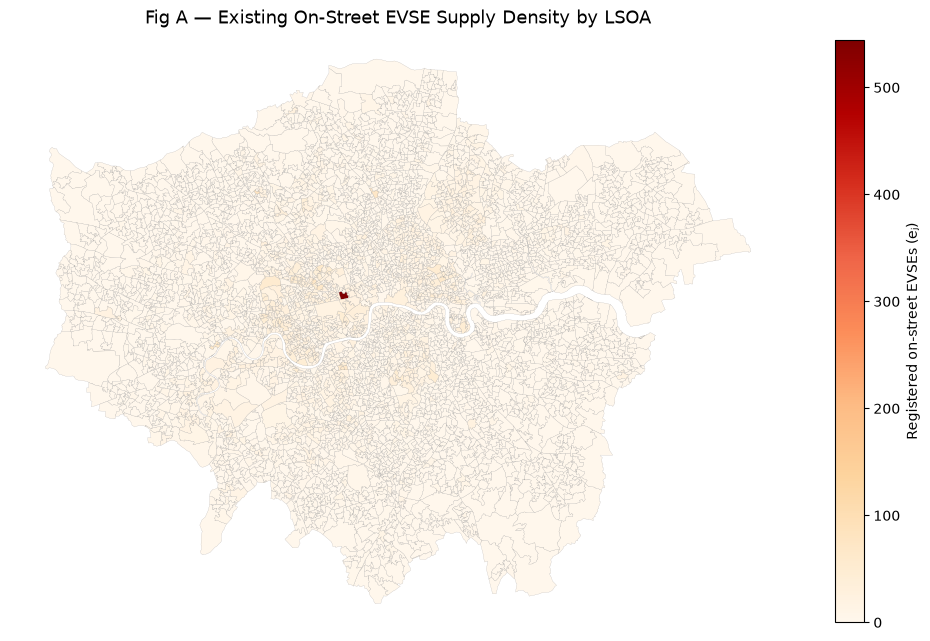

In [9]:
fig_a_map = lsoa_london.merge(seff_london[["lsoa_code", "ej"]], on="lsoa_code", how="left")
fig, ax = plt.subplots(figsize=(10, 10))
fig_a_map.plot(column="ej", cmap="OrRd", linewidth=0.1, edgecolor="grey",
               legend=True, ax=ax, legend_kwds={"label": "Registered on-street EVSEs (eⱼ)", "shrink": 0.6})
ax.set_title("Fig A — Existing On-Street EVSE Supply Density by LSOA", fontsize=13)
ax.axis("off")
plt.tight_layout()
plt.savefig(os.path.join(figures_dir, "fig_a_evse_count.png"), dpi=300, bbox_inches="tight")
plt.show()

### Fig B — mean realised utilisation (ūᵢ), "been-used" map

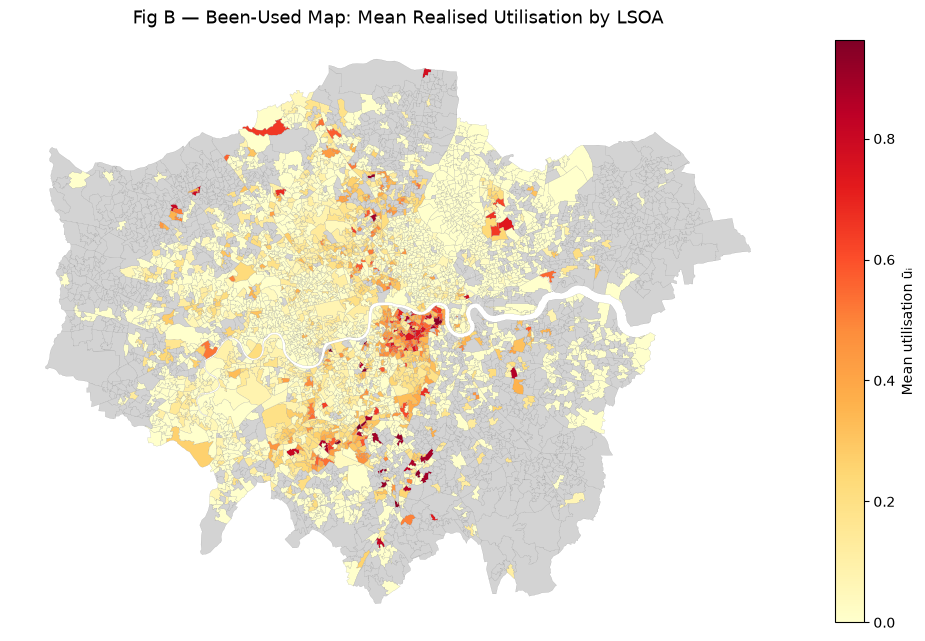

In [10]:
fig_b_map = lsoa_london.merge(seff_london[["lsoa_code", "ubar_i", "has_evse_i"]], on="lsoa_code", how="left")
fig, ax = plt.subplots(figsize=(10, 10))
fig_b_map.plot(column="ubar_i", cmap="YlOrRd", linewidth=0.1, edgecolor="grey",
               legend=True, ax=ax, missing_kwds={"color": "lightgrey", "label": "No registered EVSE"},
               legend_kwds={"label": "Mean utilisation ūᵢ", "shrink": 0.6})
ax.set_title("Fig B — Been-Used Map: Mean Realised Utilisation by LSOA", fontsize=13)
ax.axis("off")
plt.tight_layout()
plt.savefig(os.path.join(figures_dir, "fig_b_utilisation.png"), dpi=300, bbox_inches="tight")
plt.show()

### Fig C — income deprivation (income_score) per LSOA

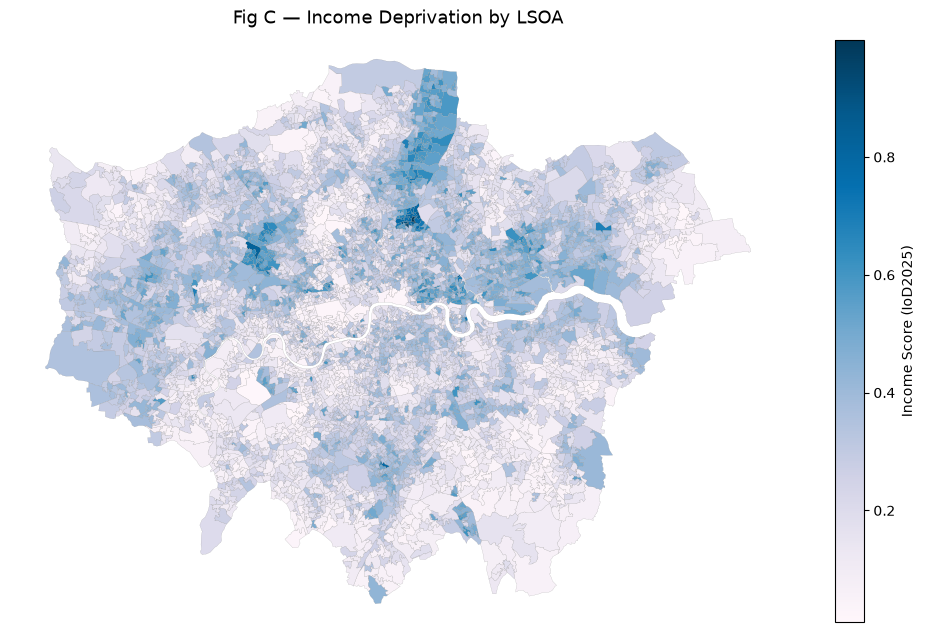

In [11]:
fig_c_map = lsoa_london.merge(imd_london[["lsoa_code", "income_score"]], on="lsoa_code", how="left")
fig, ax = plt.subplots(figsize=(10, 10))
fig_c_map.plot(column="income_score", cmap="PuBu", linewidth=0.1, edgecolor="grey",
               legend=True, ax=ax, legend_kwds={"label": "Income Score (IoD2025)", "shrink": 0.6})
ax.set_title("Fig C — Income Deprivation by LSOA", fontsize=13)
ax.axis("off")
plt.tight_layout()
plt.savefig(os.path.join(figures_dir, "fig_c_income_deprivation.png"), dpi=300, bbox_inches="tight")
plt.show()

## 5. Correlation: income score vs Sᵢᵉᶠᶠ

In [12]:
corr_table = (
    census_london[["lsoa_code", "lsoa_name", "Hi"]]
    .merge(imd_london[["lsoa_code", "income_score", "income_decile"]], on="lsoa_code")
    .merge(seff_london[["lsoa_code", "ej", "seff", "ubar_i", "has_evse_i"]], on="lsoa_code")
)
corr_table["ej_per_1000_hh"]   = corr_table["ej"]   / corr_table["Hi"] * 1000
corr_table["seff_per_1000_hh"] = corr_table["seff"] / corr_table["Hi"] * 1000

pairs = [
    ("income_score", "ej_per_1000_hh",   "Income score vs on-street EVSE count per 1,000 households"),
    ("income_score", "seff_per_1000_hh", "Income score vs Sᵢᵉᶠᶠ per 1,000 households"),
]
print("=== Pearson correlations ===")
for col_x, col_y, label in pairs:
    sub = corr_table.dropna(subset=[col_x, col_y])
    r, p = pearsonr(sub[col_x], sub[col_y])
    print(f"{label}: r = {r:.4f}, p = {p:.4g}, n = {len(sub)}")

output_path = os.path.join(BASE, "05_processed/correlation_results.csv")
pd.DataFrame(
    [(l, *pearsonr(corr_table.dropna(subset=[x,y])[x], corr_table.dropna(subset=[x,y])[y]), len(corr_table.dropna(subset=[x,y])))
     for x,y,l in pairs], columns=["pair","pearson_r","p_value","n"]
).to_csv(output_path, index=False)
print(f"\nSaved to: {output_path}")

=== Pearson correlations ===
Income score vs on-street EVSE count per 1,000 households: r = -0.0589, p = 3.155e-05, n = 4994
Income score vs Sᵢᵉᶠᶠ per 1,000 households: r = -0.0639, p = 6.269e-06, n = 4994

Saved to: /Users/alexia/Documents/CASA/Dissertation/05_processed/correlation_results.csv


### Optional robustness check (subject to time and diagnostics)

Prior run on the unfiltered eⱼ found Moran's I = 0.386 (p=0.001) on the OLS residuals —
significant spatial autocorrelation, so a full SAR regression is warranted per the
proposal's declared rule. Re-run this on the on-street-filtered numbers below.

In [13]:
try:
    import libpysal
    from esda.moran import Moran
    import statsmodels.api as sm

    reg_data = corr_table.dropna(subset=["income_score", "seff_per_1000_hh"]).copy()
    X = sm.add_constant(reg_data["income_score"])
    ols = sm.OLS(reg_data["seff_per_1000_hh"], X).fit()
    reg_data["resid"] = ols.resid

    reg_geo = lsoa_london.merge(reg_data[["lsoa_code", "resid"]], on="lsoa_code")
    w = libpysal.weights.Queen.from_dataframe(reg_geo)
    w.transform = "r"
    moran = Moran(reg_geo["resid"].values, w)
    print(f"Moran's I on OLS residuals: {moran.I:.4f}, p = {moran.p_sim:.4f}")
    if moran.p_sim < 0.05:
        print("Significant residual spatial autocorrelation -- a full spatial-lag/SAR")
        print("regression is warranted as a robustness check (proposal Section 7).")
    else:
        print("No significant residual spatial autocorrelation -- plain Pearson r stands.")
except ImportError:
    print("esda/libpysal/statsmodels not installed -- optional, skip for now.")

/var/folders/ns/mq6gshc5381576s51jjzgybm0000gn/T/ipykernel_43655/2241814336.py:12: FutureWarning: `use_index` defaults to False but will default to True in future. Set True/False directly to control this behavior and silence this warning
  w = libpysal.weights.Queen.from_dataframe(reg_geo)


Moran's I on OLS residuals: 0.4698, p = 0.0010
Significant residual spatial autocorrelation -- a full spatial-lag/SAR
regression is warranted as a robustness check (proposal Section 7).


## 6. join_august2025.csv exploration

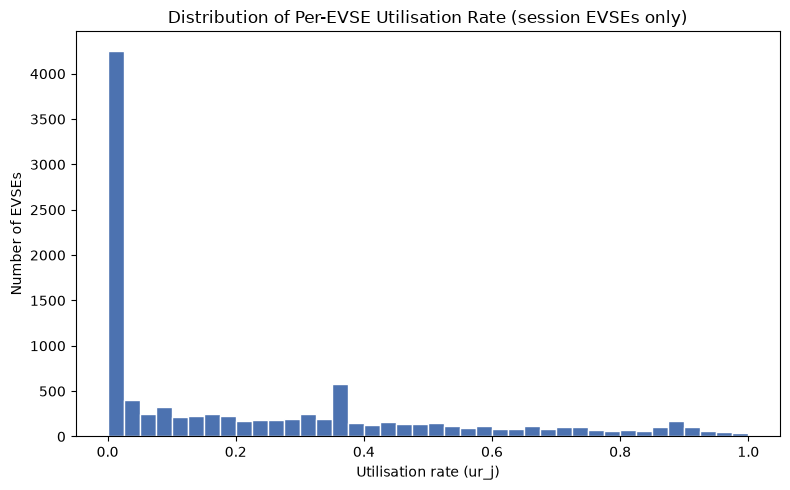

In [14]:
fig, ax = plt.subplots(figsize=(8, 5))
ax.hist(evse_ur["ur_j"], bins=40, color="#4C72B0", edgecolor="white")
ax.set_xlabel("Utilisation rate (ur_j)"); ax.set_ylabel("Number of EVSEs")
ax.set_title("Distribution of Per-EVSE Utilisation Rate (session EVSEs only)")
plt.tight_layout()
plt.savefig(os.path.join(figures_dir, "fig_ur_j_distribution.png"), dpi=300, bbox_inches="tight")
plt.show()

power_band
1. Slow           8045
2. Fast (AC)      1477
2. Fast (DC)         2
3. Rapid           385
4. Ultra-rapid     556
Name: count, dtype: int64


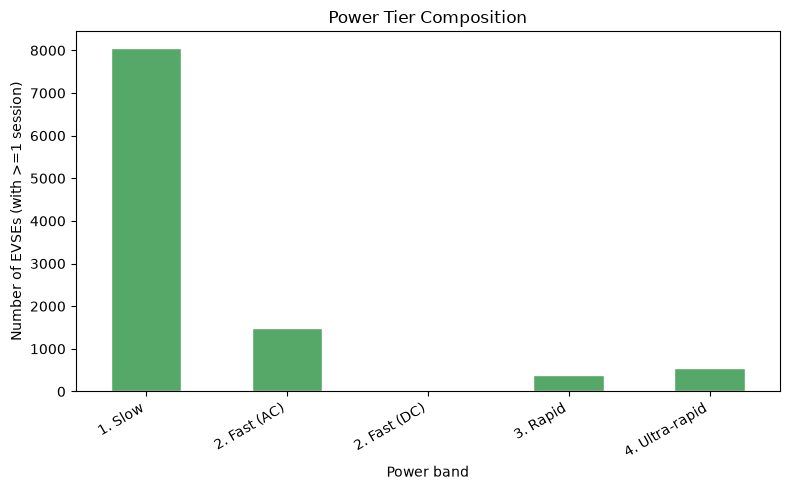

In [15]:
evse_power = zapmap_clean.groupby("evse_id")["power_band"].first().reset_index()
power_counts = evse_power["power_band"].value_counts().sort_index()
print(power_counts)

fig, ax = plt.subplots(figsize=(8, 5))
power_counts.plot(kind="bar", ax=ax, color="#55A868", edgecolor="white")
ax.set_xlabel("Power band"); ax.set_ylabel("Number of EVSEs (with >=1 session)")
ax.set_title("Power Tier Composition")
plt.xticks(rotation=30, ha="right")
plt.tight_layout()
plt.savefig(os.path.join(figures_dir, "fig_power_tier.png"), dpi=300, bbox_inches="tight")
plt.show()

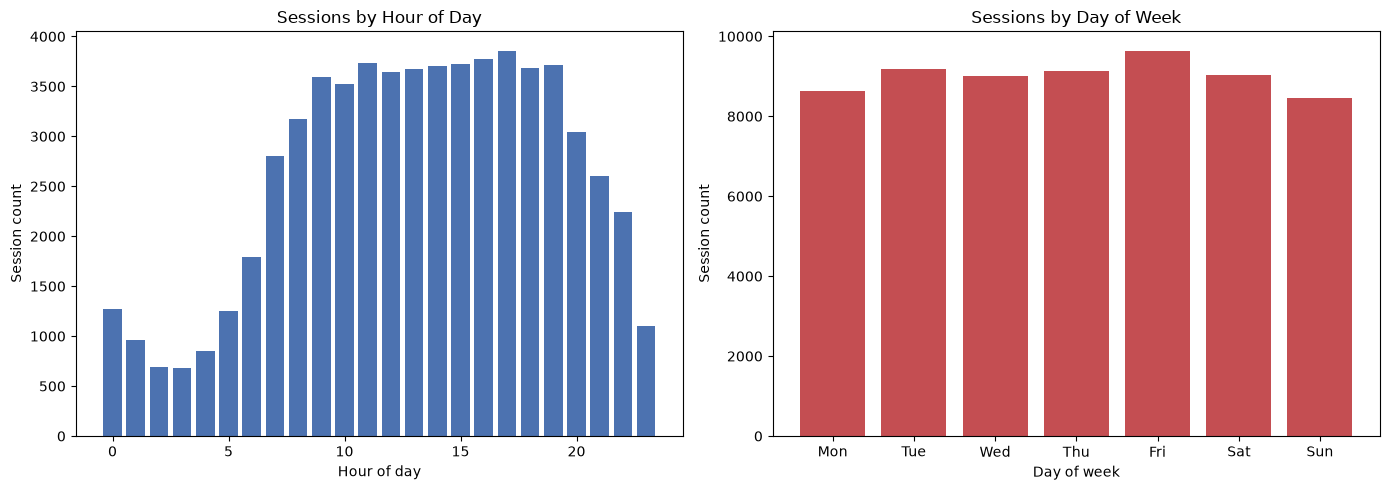

In [16]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sessions_by_hour = zapmap_clean.groupby("hour").size()
axes[0].bar(sessions_by_hour.index, sessions_by_hour.values, color="#4C72B0")
axes[0].set_xlabel("Hour of day"); axes[0].set_ylabel("Session count")
axes[0].set_title("Sessions by Hour of Day")

dow_labels = ["Mon","Tue","Wed","Thu","Fri","Sat","Sun"]
sessions_by_dow = zapmap_clean.groupby("dayofweek").size()
axes[1].bar([dow_labels[i] for i in sessions_by_dow.index], sessions_by_dow.values, color="#C44E52")
axes[1].set_xlabel("Day of week"); axes[1].set_ylabel("Session count")
axes[1].set_title("Sessions by Day of Week")
plt.tight_layout()
plt.savefig(os.path.join(figures_dir, "fig_temporal_patterns.png"), dpi=300, bbox_inches="tight")
plt.show()

## 7. Update pipeline_summary.csv

In [17]:
pipeline_summary = pd.read_csv(os.path.join(BASE, "05_processed/pipeline_summary.csv"))
updates = {
    "EVSEs matched to LSOA via spatial join": str(matched),
    "eⱼ / Sᵢᵉᶠᶠ / Uᵢ / has_evse_i (LSOA-level)": f"Done (on-street only) — {seff_london['has_evse_i'].sum()} LSOAs with has_evse_i=True",
}
for item, value in updates.items():
    if (pipeline_summary["Item"] == item).any():
        pipeline_summary.loc[pipeline_summary["Item"] == item, "Count"] = value
    else:
        pipeline_summary = pd.concat([pipeline_summary, pd.DataFrame([{"Item": item, "Count": value}])], ignore_index=True)

pipeline_summary.to_csv(os.path.join(BASE, "05_processed/pipeline_summary.csv"), index=False)
print(pipeline_summary.to_string(index=False))

                                                   Item                                                   Count
                          LSOAs loaded (Greater London)                                                    4994
      Household total (Hi sum, validated vs gor:London)                                                 3423845
Total EVSE locations (OpenStreetEV_GLA, all categories)                                                   23015
            On-street EVSE locations (OpenStreetEV_GLA)                                                   21366
          Session records (join_august2025, post-clean)                                                   63105
          Unique EVSEs with >=1 session (ur_j computed)                                                   10465
              eⱼ / Sᵢᵉᶠᶠ / Uᵢ / has_evse_i (LSOA-level) Done (on-street only) — 3157 LSOAs with has_evse_i=True
                 EVSEs matched to LSOA via spatial join                                                 